# Forecasting Emergency Department Visit Volume with Exponential Smoothing (PROC ESM)


## Executive Summary

A mid-size hospital system needs a year-ahead forecast of monthly emergency department (ED) visit volume to plan nurse staffing and bed capacity ahead of the winter respiratory surge. This notebook builds a synthetic four-year monthly ED census (48 months, Jan 2021 - Dec 2024) and fits a Winters multiplicative seasonal model with **PROC ESM** to produce a 12-month forecast with 95% prediction intervals.

The fitted model captures the series well: in-sample **RMSE is about 320 visits** and **MAPE is 4.16%**, so typical monthly error is under 5% of volume. The forecast projects the familiar seasonal shape into 2025 - a December-February peak near **7,300-7,800 visits/month** and a late-summer trough near **5,800-5,900** - with prediction bands that widen as the horizon extends. Those numbers, and the smoothing weights behind them, are read directly from the procedure's output datasets below.


## Data Sources

| Dataset | Rows | Grain | Key variables | Description |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | One row per calendar month, Jan 2021 - Dec 2024 | `month` (monthly SAS date), `ed_visits` (integer monthly ED visit count) | Synthetic monthly emergency-department visit volume for a mid-size hospital system. Generated with an upward growth trend (~3% annual), a multiplicative seasonal cycle peaking in winter respiratory season (Dec-Feb) and dipping in late summer, plus log-normal noise so the seasonal amplitude scales with the rising level. |


# Forecasting Emergency Department Visit Volume with PROC ESM

Capacity planners need to know how many ED visits to expect each month so they can schedule nurses, hold flex beds, and stage respiratory supplies before the winter surge. ED volume is a textbook seasonal time series: it grows slowly year over year, peaks during the December-February respiratory season, and ebbs in late summer, and the size of the seasonal swing grows as the baseline volume grows. That multiplicative seasonal structure is exactly what the Winters multiplicative method in **PROC ESM** is designed to capture.

In this notebook we:

1. Generate a realistic four-year monthly ED census with trend, multiplicative seasonality, and noise.
2. Visualize the series to confirm its multiplicative seasonal structure.
3. Fit a Winters multiplicative model with PROC ESM and read its smoothing weights and fit statistics from the output datasets.
4. Produce a 12-month-ahead forecast with 95% prediction intervals and interpret the operational implications.


## Step 1 - Generate the synthetic monthly ED census

We build 48 monthly observations from January 2021 through December 2024. Each month's expected volume is a baseline level that grows about 3% per year, multiplied by a seasonal index (highest in mid-winter, lowest in late summer), then perturbed by log-normal noise so the random variation scales with the level. `intnx` advances the month-aligned date one period per row, and `streaminit` makes the draw reproducible.


In [1]:
data ed_census;
    call streaminit(20240531);
    /* Monthly seasonal index: peaks Dec-Feb (flu/RSV), troughs Aug-Sep */
    array seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    format month yymmn6.;
    do i = 1 to 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* Baseline ~6000 visits/mo growing ~3% per year */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* Multiplicative seasonality + level-scaled lognormal noise */
        noise = exp(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        output;
    end;
    keep month ed_visits;
run;

proc print data=ed_census(obs=14) noobs label;
    label month = 'Month' ed_visits = 'ED Visits';
    title 'First 14 Months of Synthetic ED Visit Volume';
run;


                                      First 14 Months of Synthetic ED Visit Volume                                      

 Month  ED Visits
202101       7103
202102       6835
202103       6668
202104       5611
202105       5816
202106       5383
202107       5586
202108       5283
202109       5161
202110       6109
202111       6451
202112       6730
202201       6847
202202       7213

... 34 more observations (showing 14 of 48)



NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


The first months confirm the design: volume opens near 7,100 in the January 2021 peak, falls through spring and summer to its August-September trough, then climbs back into the next winter. By January 2022 the peak has edged up to about 6,800-7,200, reflecting the ~3% annual growth layered onto the seasonal cycle.


## Step 2 - Visualize the series

Before modeling, plot the raw series to confirm the structure we expect: a gentle upward trend with a repeating annual peak each winter whose amplitude widens over time. A widening seasonal swing is the signature of a *multiplicative* seasonal process and tells us which ESM model to choose.


                                      First 14 Months of Synthetic ED Visit Volume                                      



NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


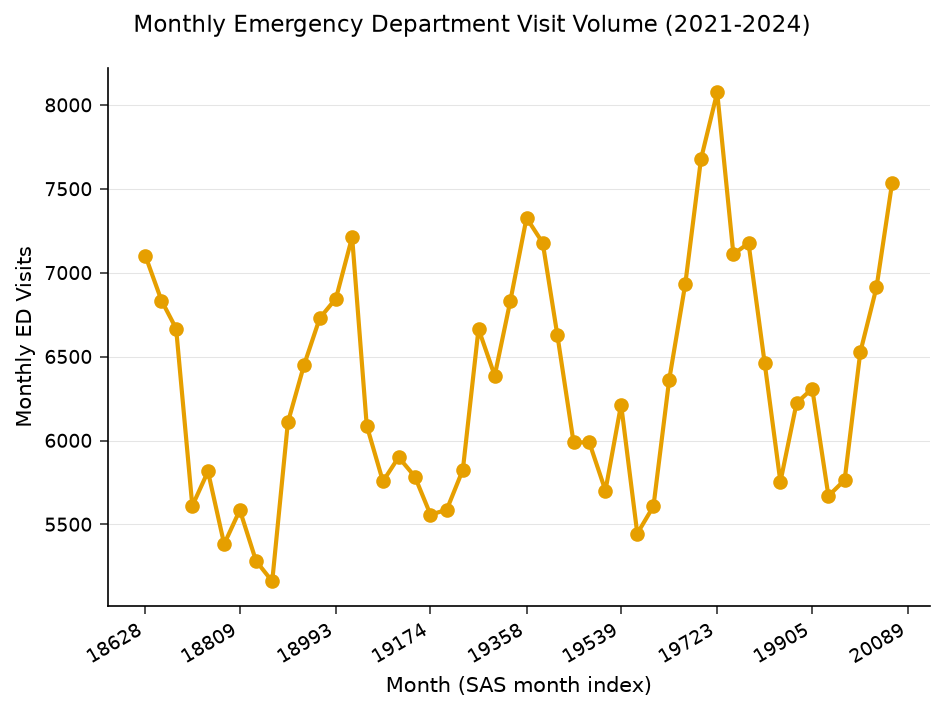

In [2]:
proc sgplot data=ed_census;
    series x=month y=ed_visits / markers
        markerattrs=(symbol=circlefilled)
        lineattrs=(thickness=2);
    xaxis label='Month (SAS month index)';
    yaxis label='Monthly ED Visits' grid;
    title 'Monthly Emergency Department Visit Volume (2021-2024)';
run;


The plot shows four clean annual cycles. Each winter peak sits a little higher than the last, climbing from roughly 7,100 in 2021 to about 8,100 at the 2024 peak, while the summer troughs rise more modestly - the seasonal swing grows with the level. That widening amplitude is the hallmark of multiplicative seasonality and justifies `MODEL=WINTERS` (Winters multiplicative) in the next step.


## Step 3 - Fit the Winters multiplicative model

We fit Winters multiplicative seasonal smoothing on the full 48-month history. The `ID` statement declares `month` as the time index at a `MONTH` interval, and the `FORECAST` statement requests `MODEL=WINTERS` with `LEAD=12` to project a year ahead. We capture three output datasets:

- `OUT=` - the historical series with the forecast appended (one `ed_visits` column), with the time ID extended over the forecast horizon - ideal for plotting.
- `OUTFOR=` - the per-period forecast components: point forecast (`PREDICT`) and the lower/upper prediction limits.
- `OUTSUM=` - the model's fit statistics (RMSE, MAE, MAPE, AIC) and smoothing weights, in a single summary row.

`ALPHA=0.05` yields 95% prediction limits, appropriate for capacity-planning risk margins. `PRINT=(STATISTICS)` echoes the fit statistics and smoothing weights to the listing.


In [3]:
proc esm data=ed_census
        lead=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        print=(statistics);
    id month interval=month;
    forecast ed_visits / model=winters alpha=0.05;
run;

proc print data=esm_summary noobs label;
    label rmse='RMSE' mae='MAE' mape='MAPE'
          alpha='Level (alpha)' beta='Trend (beta)' gamma='Season (gamma)';
    var rmse mae mape alpha beta gamma;
    title 'Winters Fit Statistics and Smoothing Weights';
run;


                                      First 14 Months of Synthetic ED Visit Volume                                      


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                                      Winters Fit Statistics and Smoothing Weights                                      

          RMSE            MAE         MA

NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


The `OUTSUM=` row and the printed statistics agree: the Winters multiplicative fit achieves an in-sample **RMSE of 320.4 visits**, **MAE of 264.4**, and **MAPE of 4.16%** - a typical monthly error well under 5% of volume, which is comfortably accurate for staffing planning. The smoothing weights are **alpha = 0.30** (level), **beta = 0.10** (trend), and **gamma = 0.10** (season). The moderate level weight lets the baseline drift upward with patient-population growth, while the small trend and season weights reflect that the growth rate and the winter-surge shape are stable year to year and should not be over-reacted to from month to month.

> Note: these are *in-sample* fit statistics computed over the estimation sample, not an out-of-sample holdout. They quantify how closely the model tracks the history it was fit on.


## Step 4 - Assemble and tabulate the 12-month forecast

The `OUTFOR=` dataset holds the point forecast and prediction limits for every period, while the `OUT=` dataset carries the time ID extended cleanly over the forecast horizon. We align the two by observation order to attach the forecast dates to the prediction limits, then keep just the 12 forecast months. These are the numbers a staffing committee would act on.


In [4]:
/* OUT= carries the forecast-horizon dates; OUTFOR= carries the
   prediction limits. Align them by observation order to put dates on
   the limits, then keep only the 12 forecast months.            */
data out_idx;
    set ed_with_forecast;
    row = _n_;
    rename month = fdate ed_visits = series_value;
run;

data for_idx;
    set esm_forecast;
    row = _n_;
    rename ed_visits = observed;
    keep row observed predict lower upper;
run;

data forecast_path;
    merge out_idx for_idx;
    by row;
    format fdate yymmn6. series_value observed predict lower upper comma8.0;
run;

data forecast_horizon;
    set forecast_path;
    where observed = .;   /* forecast months only (no observed value) */
    keep fdate predict lower upper;
run;

proc print data=forecast_horizon noobs label;
    label fdate   = 'Month'
          predict = 'Forecast Visits'
          lower   = '95% Lower'
          upper   = '95% Upper';
    title '12-Month ED Visit Forecast with 95% Prediction Limits';
run;


                                 12-Month ED Visit Forecast with 95% Prediction Limits                                  

 Month  Forecast Visits  95% Lower  95% Upper
202501            7,822      7,194      8,450
202502            7,539      6,651      8,427
202503            7,292      6,204      8,380
202504            6,263      5,007      7,519
202505            6,397      4,992      7,801
202506            6,039      4,501      7,578
202507            6,236      4,574      7,897
202508            5,867      4,091      7,644
202509            5,802      3,918      7,686
202510            6,804      4,818      8,790
202511            7,173      5,090      9,256
202512            7,567      5,391      9,742



NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


The forecast carries the seasonal signature forward into 2025. The model projects the January 2025 peak at about **7,822 visits** (95% interval 7,194-8,450), eases through spring, bottoms out in the late-summer trough near **5,802** in September (interval 3,918-7,686), then rebuilds to a December peak of roughly **7,567** (interval 5,391-9,742). The prediction band widens steadily with the horizon - next month's interval spans about +/-630 visits, while next December's spans more than +/-2,000 - a direct reminder that near-term plans are far firmer than year-end ones.


## Step 5 - Plot history plus forecast

Finally, overlay the forecast on the observed history so planners can see the projected winter peak and the widening uncertainty band as the horizon extends. We split the aligned `forecast_path` series into the **observed** history (solid) and the **12-month forecast** (dashed) so the handoff is clear, and draw the 95% prediction band underneath. The x-axis is the monthly SAS date index, running left-to-right from Jan 2021 through Dec 2025.


                                 12-Month ED Visit Forecast with 95% Prediction Limits                                  



NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


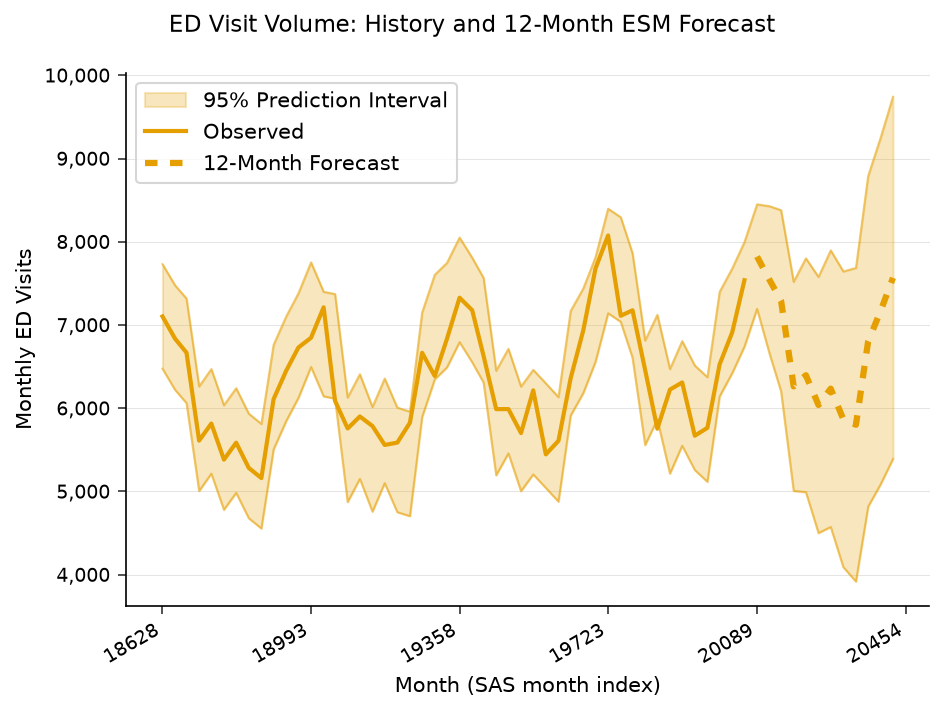

In [5]:
/* Split the projected series into the observed history and the
   12-month forecast so they render with distinct styling, and overlay
   the 95% prediction band from the aligned forecast_path dataset.   */
data forecast_plot;
    set forecast_path;
    if observed = . then fc_only = predict;   /* future months only */
    else fc_only = .;
run;

proc sgplot data=forecast_plot;
    band x=fdate lower=lower upper=upper /
        legendlabel='95% Prediction Interval' transparency=0.5;
    series x=fdate y=observed / lineattrs=(thickness=2)
        legendlabel='Observed';
    series x=fdate y=fc_only / lineattrs=(thickness=3 pattern=shortdash)
        legendlabel='12-Month Forecast';
    xaxis label='Month (SAS month index)';
    yaxis label='Monthly ED Visits' grid;
    title 'ED Visit Volume: History and 12-Month ESM Forecast';
run;


## Interpreting the results

The Winters multiplicative model decomposes ED volume into a slowly rising **level**, a near-flat **trend**, and a stable **seasonal** pattern. The smoothing weights read from `OUTSUM=` tell the story: a moderate level weight (alpha = 0.30) lets the baseline drift upward with patient-population growth, while small trend and season weights (beta = gamma = 0.10) reflect that the growth rate and the winter-surge shape are highly stable year to year and should not be over-reacted to from month to month.

The **fit statistics** confirm the model tracks the history well: an RMSE of about 320 visits and a MAPE of 4.16% mean typical monthly error is under 5% of volume. Operationally, the **forecast table and band plot** quantify the December-February peak the ED should staff toward - roughly 7,300-7,800 visits in the winter months - and the 95% prediction limits define a prudent capacity range: plan core staffing to the point forecast, and pre-arrange flex coverage and surge beds toward the upper limit. The interval widens with the horizon, so next month's plan is far firmer than next December's and should be refreshed as new actuals arrive.

**Extensions:** compare `MODEL=ADDWINTERS` (additive seasonality) against the multiplicative fit to confirm the multiplicative choice; apply `TRANSFORM=LOG` to enforce positivity and stabilize variance; or add a `BY` statement to forecast multiple hospital sites in a single PROC ESM call.
